In [2]:
import jax
import jax.numpy as jnp
import numpy as np
from flax import nnx
import optax
import grain.python as grain
import orbax.checkpoint as ocp

DATASET_PATH="./ranking_dataset.csv"
RANDOM_SEED=14

In [3]:

class RoPE(nnx.Module):
    def __init__(self, head_dim: int, max_seq_len: int = 4096, base: float = 10000.0):
        if head_dim % 2 != 0:
            raise ValueError(f"head_dim must be even. Got {head_dim}")
            
        # Compute angles
        inv_freq = 1.0 / (base ** (jnp.arange(0, head_dim, 2) / head_dim))
        positions = jnp.arange(max_seq_len)
        angles = jnp.outer(positions, inv_freq)
        
        # Cache complex exponentials e^(i * theta)
        complex_freqs = jnp.exp(1j * angles)
        self.complex_freqs = nnx.Cache(complex_freqs)

    def __call__(self, x: jax.Array) -> jax.Array:
        """
        Expects x to have shape: (batch_size, seq_len, n_heads, head_dim)
        """
        seq_len = x.shape[1]
        freqs = self.complex_freqs[...][:seq_len, :]
        
        # 2. Reshape for broadcasting: (1, seq_len, 1, head_dim // 2)
        freqs = freqs[None, :, None, :]
        
        # 3. Group head_dim into pairs: (..., head_dim // 2, 2)
        x_paired = x.reshape(*x.shape[:-1], -1, 2)
        
        # 4. Map to complex plane and multiply
        x_complex = jax.lax.complex(x_paired[..., 0], x_paired[..., 1])
        rotated_complex = x_complex * freqs
        
        # 5. Map back to real coordinates and flatten
        rotated_real = jnp.stack([rotated_complex.real, rotated_complex.imag], axis=-1)
        return rotated_real.reshape(x.shape)

In [4]:
class FeedForwardNN(nnx.Module):
    def __init__(self, d_model: int, hidden_dim: int,rngs: nnx.Rngs):
        self.w_gate= nnx.Linear(d_model, hidden_dim, use_bias=False, rngs=rngs)
        self.w_up= nnx.Linear(d_model, hidden_dim, use_bias=False, rngs=rngs)
        self.w_down= nnx.Linear(hidden_dim,d_model, use_bias=False, rngs=rngs)
    def __call__(self, x:jax.Array):
        hidden_state=self.w_up(x)*jax.nn.silu(self.w_gate(x))
        return self.w_down(hidden_state)

In [5]:
class MHSA(nnx.Module):
    def __init__(self, d_model,max_seq_len, d_k=None, n_heads=8,rngs=None):
        
        self.d_model = d_model
        self.n_heads=n_heads
        if d_k is not None: self.d_k=d_k
        else: self.d_k=d_model
        self.head_size=self.d_k//n_heads
        self.max_seq=max_seq_len
        # Linear layers for projecting input X into Q, K, V spaces
        self.w_q = nnx.Linear(d_model, self.d_k, use_bias=False, rngs=rngs)
        self.w_k = nnx.Linear(d_model, self.d_k, use_bias=False, rngs=rngs)
        self.w_v = nnx.Linear(d_model, self.d_k, use_bias=False, rngs=rngs)
        self.w_o = nnx.Linear(self.d_k, d_model, use_bias=False, rngs=rngs)
        self.RoPE=RoPE(head_dim=self.head_size,max_seq_len=max_seq_len)
        
    def __call__(self, x: jax.Array, mask: jax.Array | None = None) -> jax.Array:
        """
        x shape: (batch_size, seq_len, d_model)
        """
        batch,seq_len ,_ = x.shape
        # 1. Project inputs
        q = self.w_q(x)
        k = self.w_k(x)
        v = self.w_v(x)
        Q=q.reshape((batch,seq_len,self.n_heads,self.head_size))
        K=k.reshape((batch,seq_len,self.n_heads,self.head_size))
        V=v.reshape((batch,seq_len,self.n_heads,self.head_size))
        #apply RoPE
        Q_R=self.RoPE(Q)
        K_R=self.RoPE(K)

        #Permute matrix for computing Attention tensor
        Q_R = jnp.transpose(Q_R, (0, 2, 1, 3))
        K_R = jnp.transpose(K_R, (0, 2, 1, 3))
        V = jnp.transpose(V, (0, 2, 1, 3))
        
        # Scaled dot-product scores: (batch, n_heads, seq_len, seq_len)
        scale = 1.0 / jnp.sqrt(self.head_size)
        attn_scores = jnp.matmul(Q_R, jnp.transpose(K_R, (0, 1, 3, 2))) * scale
        if mask is not None:
            attn_scores = jnp.where(mask, attn_scores, -1e12)
        attn_weights = jax.nn.softmax(attn_scores, axis=-1)
        self.sown_attn = nnx.Intermediate(attn_weights)
        # Weighted sum over values: (batch, n_heads, seq_len, head_size)
        context = jnp.matmul(attn_weights, V)
        
        # Permute back to (batch, seq_len, n_heads, head_size) and flatten heads
        context = jnp.transpose(context, (0, 2, 1, 3))
        attn_output = context.reshape((batch, seq_len, self.d_k))
        
        # Final projection
        return self.w_o(attn_output)

In [6]:


class TransformerBlock(nnx.Module):
    def __init__(self, d_model: int, n_heads: int, max_seq_len: int, rngs: nnx.Rngs):
        self.attn_norm = nnx.RMSNorm(d_model, rngs=rngs)
        self.mha = MHSA(d_model, n_heads=n_heads, max_seq_len=max_seq_len, rngs=rngs)
        
        self.ffn_norm = nnx.RMSNorm(d_model, rngs=rngs)
        hidden_dim = int((8/3) * d_model) 
        self.ffn = FeedForwardNN(d_model, hidden_dim, rngs)

    def __call__(self, x: jax.Array, mask: jax.Array | None = None) -> jax.Array:
        """
        x shape: (batch_size, seq_len, d_model)
        """
        # Phase 1: Pre-Norm Attention Residual Stream
        x_norm1 = self.attn_norm(x)
        attn_out = self.mha(x_norm1, mask)
        #x = x + attn_out  
        x=attn_out
        # Phase 2: Pre-Norm FeedForward Residual Stream
        x_norm2 = self.ffn_norm(x)
        ffn_out = self.ffn(x_norm2)
        x = x + ffn_out  
        return x

In [7]:
# Step 1: DigitRanker Transformer Encoder
import jax
import jax.numpy as jnp
import numpy as np
from flax import nnx
import optax
from typing import Any

class DigitRanker(nnx.Module):
    def __init__(self, d_model: int = 64, n_heads: int = 4, num_layers: int = 2, max_seq_len: int = 10, num_classes: int = 10,use_lape: bool=False, rngs: nnx.Rngs = None):
        self.d_model = d_model
        self.max_seq_len = max_seq_len
        self.num_classes = num_classes
        self.embed = nnx.Linear(1, d_model, rngs=rngs)
        self.pos_embed = nnx.Embed(max_seq_len, d_model, rngs=rngs) if use_lape else None
        self.transformer_blocks = nnx.List([
            TransformerBlock(d_model, n_heads, max_seq_len, rngs) for _ in range(num_layers)
        ])
        self.norm = nnx.RMSNorm(d_model, rngs=rngs)
        self.head = nnx.Linear(d_model, num_classes, rngs=rngs)

    def __call__(self, x: jax.Array) -> jax.Array:
        # x: (batch, seq_len) -- integer values
        # Min-max normalize per sequence
        x_min = x.min(axis=-1, keepdims=True)
        x_max = x.max(axis=-1, keepdims=True)
        x_norm = (x - x_min) / (x_max - x_min + 1e-8)
        x_norm = x_norm[..., None]  # (batch, seq_len, 1)
        x = self.embed(x_norm)  # (batch, seq_len, d_model)
        if self.pos_embed is not None:
            pos_ids = jnp.arange(self.max_seq_len)[None, :]
            x = x + self.pos_embed(pos_ids)
        for block in self.transformer_blocks:
            x = block(x)
        x = self.norm(x)
        logits = self.head(x)  # (batch, seq_len, num_classes)
        return logits


In [8]:
# Define Baseline Models: MLPRanker and LSTMRanker

class MLPRanker(nnx.Module):
    def __init__(self, input_dim: int = 10, hidden_dims: list = [128, 256, 128], num_classes: int = 10, rngs: nnx.Rngs = None):
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.layers = nnx.List([
            nnx.Linear(input_dim if i == 0 else hidden_dims[i-1], h, rngs=rngs)
            for i, h in enumerate(hidden_dims)
        ])
        self.head = nnx.Linear(hidden_dims[-1], input_dim * num_classes, rngs=rngs)

    def __call__(self, x: jax.Array) -> jax.Array:
        # x: (batch, seq_len)
        # Min-max normalize per sequence
        x_min = x.min(axis=-1, keepdims=True)
        x_max = x.max(axis=-1, keepdims=True)
        x_norm = (x - x_min) / (x_max - x_min + 1e-8)
        
        h = x_norm
        for layer in self.layers:
            h = jax.nn.silu(layer(h))
        
        out = self.head(h)  # (batch, input_dim * num_classes)
        logits = out.reshape((x.shape[0], self.input_dim, self.num_classes))
        return logits

class LSTMRanker(nnx.Module):
    def __init__(self, d_model: int = 64, hidden_dim: int = 64, num_classes: int = 10, bidirectional: bool = True, rngs: nnx.Rngs = None):
        self.d_model = d_model
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes
        self.bidirectional = bidirectional
        self.embed = nnx.Linear(1, d_model, rngs=rngs)
        if bidirectional:
            fw = nnx.RNN(nnx.LSTMCell(d_model, hidden_dim // 2, rngs=rngs))
            bw = nnx.RNN(nnx.LSTMCell(d_model, hidden_dim // 2, rngs=rngs))
            self.lstm = nnx.Bidirectional(fw, bw)
        else:
            cell = nnx.LSTMCell(d_model, hidden_dim, rngs=rngs)
            self.lstm = nnx.RNN(cell)
        self.head = nnx.Linear(hidden_dim, num_classes, rngs=rngs)

    def __call__(self, x: jax.Array) -> jax.Array:
        # x: (batch, seq_len)
        # Min-max normalize per sequence
        x_min = x.min(axis=-1, keepdims=True)
        x_max = x.max(axis=-1, keepdims=True)
        x_norm = (x - x_min) / (x_max - x_min + 1e-8)
        x_norm = x_norm[..., None]  # (batch, seq_len, 1)
        
        x_embed = self.embed(x_norm)  # (batch, seq_len, d_model)
        h = self.lstm(x_embed)  # (batch, seq_len, hidden_dim)
        logits = self.head(h)  # (batch, seq_len, num_classes)
        return logits


In [9]:
# Step 2: Load dataset, split, and move to GPU
import pandas as pd
from sklearn.model_selection import train_test_split
import jax
import jax.numpy as jnp

# Load CSV
df = pd.read_csv("./ranking_dataset.csv")
val_cols = [f'val_{i}' for i in range(10)]
rank_cols = [f'rank_{i}' for i in range(10)]
X = df[val_cols].values
y = df[rank_cols].values

# Split into train, val, test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
X_train = jax.device_put(X_train)
y_train = jax.device_put(y_train)
X_val = jax.device_put(X_val)
y_val = jax.device_put(y_val)
X_test = jax.device_put(X_test)
y_test = jax.device_put(y_test)


ERROR:jax._src.xla_bridge:Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/aneesh_shastri/miniforge3/envs/ml_env/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 495, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/aneesh_shastri/miniforge3/envs/ml_env/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/home/aneesh_shastri/miniforge3/envs/ml_env/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:135: operation cuInit(0) failed: Unknown CUDA error 100; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


In [10]:
# Step 3: get_batch function
def get_batch(X, y, batch_size, key=None):
    n = X.shape[0]
    if key is None:
        idx = np.random.choice(n, batch_size, replace=False)
    else:
        idx = jax.random.choice(key, n, (batch_size,), replace=False)
    return X[idx], y[idx]


In [11]:
# Step 4: Loss, train_step, validation_step
import optax

def compute_loss(logits, targets):
    # logits: (batch, seq_len, num_classes), targets: (batch, seq_len)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, targets.astype(jnp.int32))
    return loss.mean()

@nnx.jit
def train_step(model, optimizer, batch):
    X, y = batch
    def loss_fn(model):
        logits = model(X)
        loss = compute_loss(logits, y)
        return loss, logits
    (loss, logits), grads = nnx.value_and_grad(loss_fn, has_aux=True)(model)
    optimizer.update(model, grads)
    return loss, logits

@nnx.jit
def validation_step(model, batch):
    X, y = batch
    logits = model(X)
    loss = compute_loss(logits, y)
    return loss, logits


In [ ]:
# Step 5: Model, optimizer, scheduler, EarlyStopping
import time

# Model init
d_model = 64
n_heads = 4
num_layers = 2
max_seq_len = 10
num_classes = 10
rngs  = nnx.Rngs(params=0, dropout=1)
lr=3e-4
model = DigitRanker(d_model, n_heads, num_layers, max_seq_len, num_classes, rngs=rngs)
schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0, peak_value=lr,
        warmup_steps=200, decay_steps=5000, end_value=1e-6,
    )
optimizer = nnx.Optimizer(model, optax.adamw(schedule, weight_decay=1e-4), wrt=nnx.Param)

# EarlyStopping
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state = None
    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = jax.tree.map(lambda x: x, nnx.state(model))
        else:
            self.counter += 1
        return self.counter >= self.patience


In [ ]:
# Step 5b: MLP Model initialization, optimizer, scheduler
mlp_rngs = nnx.Rngs(params=42, dropout=43)
mlp_model = MLPRanker(input_dim=10, hidden_dims=[128, 256, 128], num_classes=10, rngs=mlp_rngs)
mlp_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0, peak_value=3e-4,
    warmup_steps=200, decay_steps=5000, end_value=1e-6,
)
mlp_optimizer = nnx.Optimizer(mlp_model, optax.adamw(mlp_schedule, weight_decay=1e-4), wrt=nnx.Param)


In [ ]:
# Step 5c: LSTM Model initialization, optimizer, scheduler
lstm_rngs = nnx.Rngs(params=100, dropout=101)
lstm_model = LSTMRanker(d_model=64, hidden_dim=64, num_classes=10, bidirectional=True, rngs=lstm_rngs)
lstm_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0, peak_value=3e-4,
    warmup_steps=200, decay_steps=5000, end_value=1e-6,
)
lstm_optimizer = nnx.Optimizer(lstm_model, optax.adamw(lstm_schedule, weight_decay=1e-4), wrt=nnx.Param)


In [ ]:
# Step 6: Training loop
batch_size = 64
epochs = 100
patience = 10
steps_per_epoch = X_train.shape[0] // batch_size

es = EarlyStopping(patience=patience)

for epoch in range(epochs):
    t0 = time.time()
    train_losses = []
    for step in range(steps_per_epoch):
        batch = get_batch(X_train, y_train, batch_size)
        loss, _ = train_step(model, optimizer, batch)
        train_losses.append(loss)
    val_batch = (X_val, y_val)
    val_loss, _ = validation_step(model, val_batch)
    print(f"Epoch {epoch+1} | Train Loss: {np.mean(train_losses):.4f} | Val Loss: {val_loss:.4f} | Time: {time.time()-t0:.2f}s")
    if es.step(val_loss, model):
        print("Early stopping triggered.")
        break

if es.best_state is not None:
    nnx.update(model, es.best_state)
    print("Restored best model state.")


Epoch 1 | Train Loss: 2.3152 | Val Loss: 1.9856 | Time: 18.80s
Epoch 2 | Train Loss: 1.7451 | Val Loss: 1.4313 | Time: 5.75s
Epoch 3 | Train Loss: 1.0610 | Val Loss: 0.9102 | Time: 1.61s
Epoch 4 | Train Loss: 0.8502 | Val Loss: 0.8718 | Time: 1.46s
Epoch 5 | Train Loss: 0.7322 | Val Loss: 0.6908 | Time: 1.61s
Epoch 6 | Train Loss: 0.6624 | Val Loss: 0.6398 | Time: 1.51s
Epoch 7 | Train Loss: 0.6169 | Val Loss: 0.6599 | Time: 1.38s
Epoch 8 | Train Loss: 0.5881 | Val Loss: 0.6363 | Time: 1.54s
Epoch 9 | Train Loss: 0.5424 | Val Loss: 0.5003 | Time: 1.47s
Epoch 10 | Train Loss: 0.4738 | Val Loss: 0.5378 | Time: 1.83s
Epoch 11 | Train Loss: 0.4655 | Val Loss: 0.4358 | Time: 1.46s
Epoch 12 | Train Loss: 0.4288 | Val Loss: 0.4255 | Time: 1.62s
Epoch 13 | Train Loss: 0.4059 | Val Loss: 0.5963 | Time: 1.47s
Epoch 14 | Train Loss: 0.3987 | Val Loss: 0.3563 | Time: 1.44s
Epoch 15 | Train Loss: 0.3581 | Val Loss: 0.3707 | Time: 1.46s
Epoch 16 | Train Loss: 0.3432 | Val Loss: 0.3212 | Time: 1.60s


In [ ]:
# Step 6b: MLP Training loop
mlp_es = EarlyStopping(patience=patience)

for epoch in range(epochs):
    t0 = time.time()
    train_losses = []
    for step in range(steps_per_epoch):
        batch = get_batch(X_train, y_train, batch_size)
        loss, _ = train_step(mlp_model, mlp_optimizer, batch)
        train_losses.append(loss)
    val_batch = (X_val, y_val)
    val_loss, _ = validation_step(mlp_model, val_batch)
    print(f"MLP Epoch {epoch+1} | Train Loss: {np.mean(train_losses):.4f} | Val Loss: {val_loss:.4f} | Time: {time.time()-t0:.2f}s")
    if mlp_es.step(val_loss, mlp_model):
        print("MLP Early stopping triggered.")
        break

if mlp_es.best_state is not None:
    nnx.update(mlp_model, mlp_es.best_state)
    print("Restored best MLP model state.")


MLP Epoch 1 | Train Loss: 2.2904 | Val Loss: 2.2563 | Time: 2.89s
MLP Epoch 2 | Train Loss: 2.0804 | Val Loss: 1.7823 | Time: 1.13s
MLP Epoch 3 | Train Loss: 1.5635 | Val Loss: 1.4227 | Time: 1.05s
MLP Epoch 4 | Train Loss: 1.3370 | Val Loss: 1.2978 | Time: 1.03s
MLP Epoch 5 | Train Loss: 1.2549 | Val Loss: 1.2410 | Time: 0.98s
MLP Epoch 6 | Train Loss: 1.2101 | Val Loss: 1.2038 | Time: 0.93s
MLP Epoch 7 | Train Loss: 1.1779 | Val Loss: 1.1994 | Time: 0.95s
MLP Epoch 8 | Train Loss: 1.1593 | Val Loss: 1.1563 | Time: 0.89s
MLP Epoch 9 | Train Loss: 1.1385 | Val Loss: 1.1489 | Time: 0.87s
MLP Epoch 10 | Train Loss: 1.1247 | Val Loss: 1.1275 | Time: 0.84s
MLP Epoch 11 | Train Loss: 1.1074 | Val Loss: 1.1141 | Time: 0.89s
MLP Epoch 12 | Train Loss: 1.0913 | Val Loss: 1.0962 | Time: 0.90s
MLP Epoch 13 | Train Loss: 1.0784 | Val Loss: 1.0815 | Time: 0.92s
MLP Epoch 14 | Train Loss: 1.0627 | Val Loss: 1.0686 | Time: 0.84s
MLP Epoch 15 | Train Loss: 1.0531 | Val Loss: 1.0658 | Time: 0.89s
MLP 

In [ ]:
# Step 6c: LSTM Training loop
lstm_es = EarlyStopping(patience=patience)

for epoch in range(epochs):
    t0 = time.time()
    train_losses = []
    for step in range(steps_per_epoch):
        batch = get_batch(X_train, y_train, batch_size)
        loss, _ = train_step(lstm_model, lstm_optimizer, batch)
        train_losses.append(loss)
    val_batch = (X_val, y_val)
    val_loss, _ = validation_step(lstm_model, val_batch)
    print(f"LSTM Epoch {epoch+1} | Train Loss: {np.mean(train_losses):.4f} | Val Loss: {val_loss:.4f} | Time: {time.time()-t0:.2f}s")
    if lstm_es.step(val_loss, lstm_model):
        print("LSTM Early stopping triggered.")
        break

if lstm_es.best_state is not None:
    nnx.update(lstm_model, lstm_es.best_state)
    print("Restored best LSTM model state.")


LSTM Epoch 1 | Train Loss: 2.3188 | Val Loss: 2.2307 | Time: 4.07s
LSTM Epoch 2 | Train Loss: 2.0082 | Val Loss: 1.7449 | Time: 1.83s
LSTM Epoch 3 | Train Loss: 1.6143 | Val Loss: 1.5189 | Time: 1.74s
LSTM Epoch 4 | Train Loss: 1.4471 | Val Loss: 1.3842 | Time: 2.20s
LSTM Epoch 5 | Train Loss: 1.3183 | Val Loss: 1.2624 | Time: 1.94s
LSTM Epoch 6 | Train Loss: 1.2144 | Val Loss: 1.1768 | Time: 1.82s
LSTM Epoch 7 | Train Loss: 1.1409 | Val Loss: 1.1120 | Time: 1.67s
LSTM Epoch 8 | Train Loss: 1.0835 | Val Loss: 1.0610 | Time: 1.65s
LSTM Epoch 9 | Train Loss: 1.0371 | Val Loss: 1.0211 | Time: 1.71s
LSTM Epoch 10 | Train Loss: 1.0019 | Val Loss: 0.9870 | Time: 1.67s
LSTM Epoch 11 | Train Loss: 0.9694 | Val Loss: 0.9595 | Time: 1.65s
LSTM Epoch 12 | Train Loss: 0.9461 | Val Loss: 0.9366 | Time: 1.67s
LSTM Epoch 13 | Train Loss: 0.9238 | Val Loss: 0.9167 | Time: 1.88s
LSTM Epoch 14 | Train Loss: 0.9030 | Val Loss: 0.8993 | Time: 1.67s
LSTM Epoch 15 | Train Loss: 0.8911 | Val Loss: 0.8838 | T

In [ ]:
# Step 7: Evaluation on test set
from sklearn.metrics import accuracy_score

def evaluate(model, X, y):
    logits = model(X)
    preds = jnp.argmax(logits, axis=-1)
    acc = (preds == y).mean()
    # Exact sequence accuracy
    exact_seq_acc = ((preds == y).all(axis=1)).mean()
    return float(acc), float(exact_seq_acc)

test_acc, test_exact_acc = evaluate(model, X_test, y_test)
print(f"Test Token Accuracy: {test_acc:.4f}")
print(f"Test Exact Sequence Accuracy: {test_exact_acc:.4f}")


Test Token Accuracy: 0.9135
Test Exact Sequence Accuracy: 0.4390


In [ ]:
# Step 7b: MLP Evaluation on test set
mlp_test_acc, mlp_test_exact_acc = evaluate(mlp_model, X_test, y_test)
print(f"MLP Test Token Accuracy: {mlp_test_acc:.4f}")
print(f"MLP Test Exact Sequence Accuracy: {mlp_test_exact_acc:.4f}")


MLP Test Token Accuracy: 0.5839
MLP Test Exact Sequence Accuracy: 0.0110


In [ ]:
# Step 7c: LSTM Evaluation on test set
lstm_test_acc, lstm_test_exact_acc = evaluate(lstm_model, X_test, y_test)
print(f"LSTM Test Token Accuracy: {lstm_test_acc:.4f}")
print(f"LSTM Test Exact Sequence Accuracy: {lstm_test_exact_acc:.4f}")


LSTM Test Token Accuracy: 0.6798
LSTM Test Exact Sequence Accuracy: 0.0230


In [ ]:
# Step 7d: Comparison of all models
import pandas as pd

comparison_data = {
    "Model": ["Transformer (DigitRanker)", "MLP Baseline (MLPRanker)", "LSTM Baseline (LSTMRanker)"],
    "Test Token Accuracy": [test_acc, mlp_test_acc, lstm_test_acc],
    "Test Exact Sequence Accuracy": [test_exact_acc, mlp_test_exact_acc, lstm_test_exact_acc]
}

comparison_df = pd.DataFrame(comparison_data)
print("| " + " | ".join(comparison_df.columns) + " |")
print("| " + " | ".join(["---"] * len(comparison_df.columns)) + " |")
for idx, row in comparison_df.iterrows():
    print("| " + " | ".join(f"{val:.4f}" if isinstance(val, float) else str(val) for val in row) + " |")


| Model | Test Token Accuracy | Test Exact Sequence Accuracy |
| --- | --- | --- |
| Transformer (DigitRanker) | 0.9135 | 0.4390 |
| MLP Baseline (MLPRanker) | 0.5839 | 0.0110 |
| LSTM Baseline (LSTMRanker) | 0.6798 | 0.0230 |


In [ ]:
# Step 8: Visualization Utilities
import matplotlib.pyplot as plt
import seaborn as sns
import jax.numpy as jnp
import numpy as np

def stable_rank(seq):
    # Compute ground truth stable rank for an input sequence
    indices = np.argsort(seq, kind='stable')
    ranks = np.empty_like(indices)
    ranks[indices] = np.arange(len(seq))
    return ranks

def plot_attention_heatmaps(model, seq, pred_ranks, gt_ranks, title=""):
    x_input = jnp.array([seq], dtype=jnp.float32)
    logits = model(x_input)
    
    # Extract attention weights from all transformer blocks
    num_layers = len(model.transformer_blocks)
    n_heads = model.transformer_blocks[0].mha.n_heads
    
    fig, axes = plt.subplots(num_layers, n_heads, figsize=(4 * n_heads, 3.5 * num_layers))
    if num_layers == 1:
        axes = np.expand_dims(axes, axis=0)
    if n_heads == 1:
        axes = np.expand_dims(axes, axis=1)
        
    labels = [str(int(val)) for val in seq]
    
    for l_idx, block in enumerate(model.transformer_blocks):
        # Access the Intermediate variable value
        attn_weights = block.mha.sown_attn[...]
        attn_weights = np.array(attn_weights[0])  # (n_heads, seq_len, seq_len)
        
        for h_idx in range(n_heads):
            ax = axes[l_idx, h_idx]
            sns.heatmap(
                attn_weights[h_idx], 
                annot=True, 
                fmt=".2f", 
                cmap="viridis", 
                xticklabels=labels, 
                yticklabels=labels, 
                ax=ax,
                cbar=False
            )
            ax.set_title(f"L{l_idx+1} Head {h_idx+1}")
            ax.set_xlabel("Key / Source Token")
            ax.set_ylabel("Query / Target Token")
            
    plt.suptitle(
        f"{title}\nInput: {seq}\nPred Ranks: {pred_ranks}\nGT Ranks: {gt_ranks}", 
        fontsize=14, 
        y=1.02
    )
    plt.tight_layout()
    plt.show()
    plt.savefig(f"Subtask1/Output/{title}.png")


In [ ]:
state = nnx.state(model)
state_lstm=nnx.state(lstm_model)
state_mlp=nnx.state(mlp_model)
checkpointer = ocp.StandardCheckpointer()
ckpt_dir_t="Models/Transformer2L4H"
ckpt_dir_mlp="Models/baselineMLP"
ckpt_dir_lstm="Models/baselineLSTM"
checkpointer.save(ckpt_dir_t, state, force=True)
checkpointer.save(ckpt_dir_mlp, state_mlp, force=True)
checkpointer.save(ckpt_dir_lstm, state_lstm, force=True)

SyntaxError: invalid syntax (139515850.py, line 3)

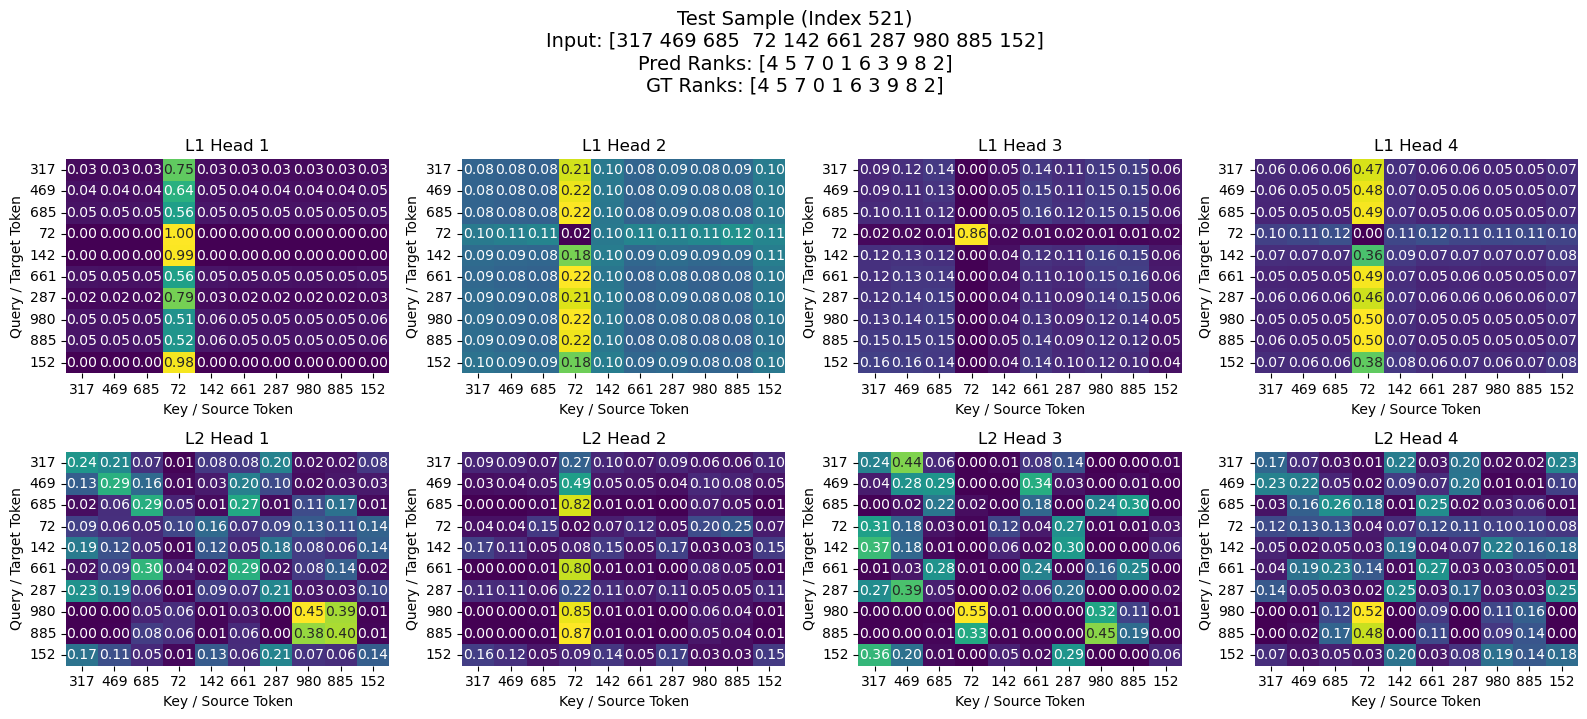

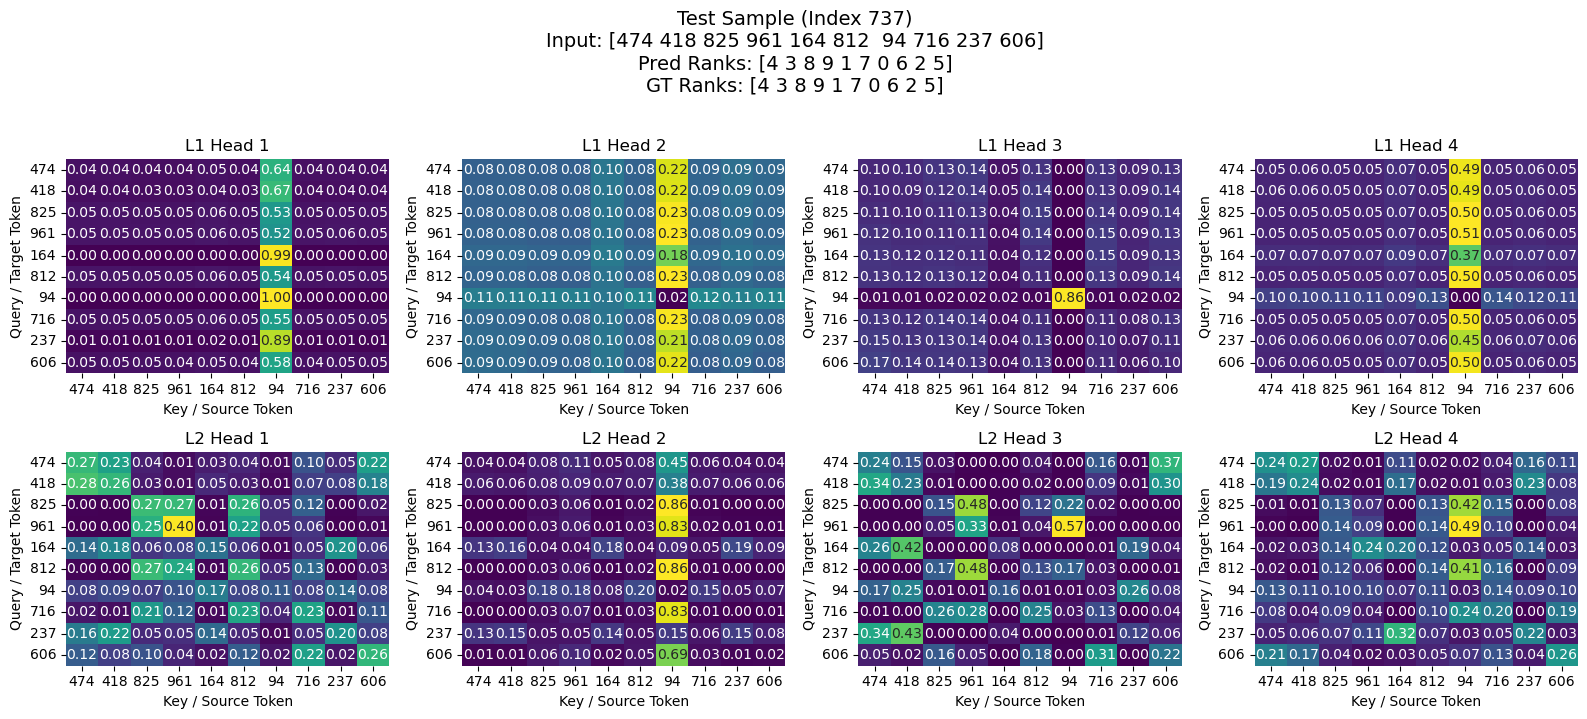

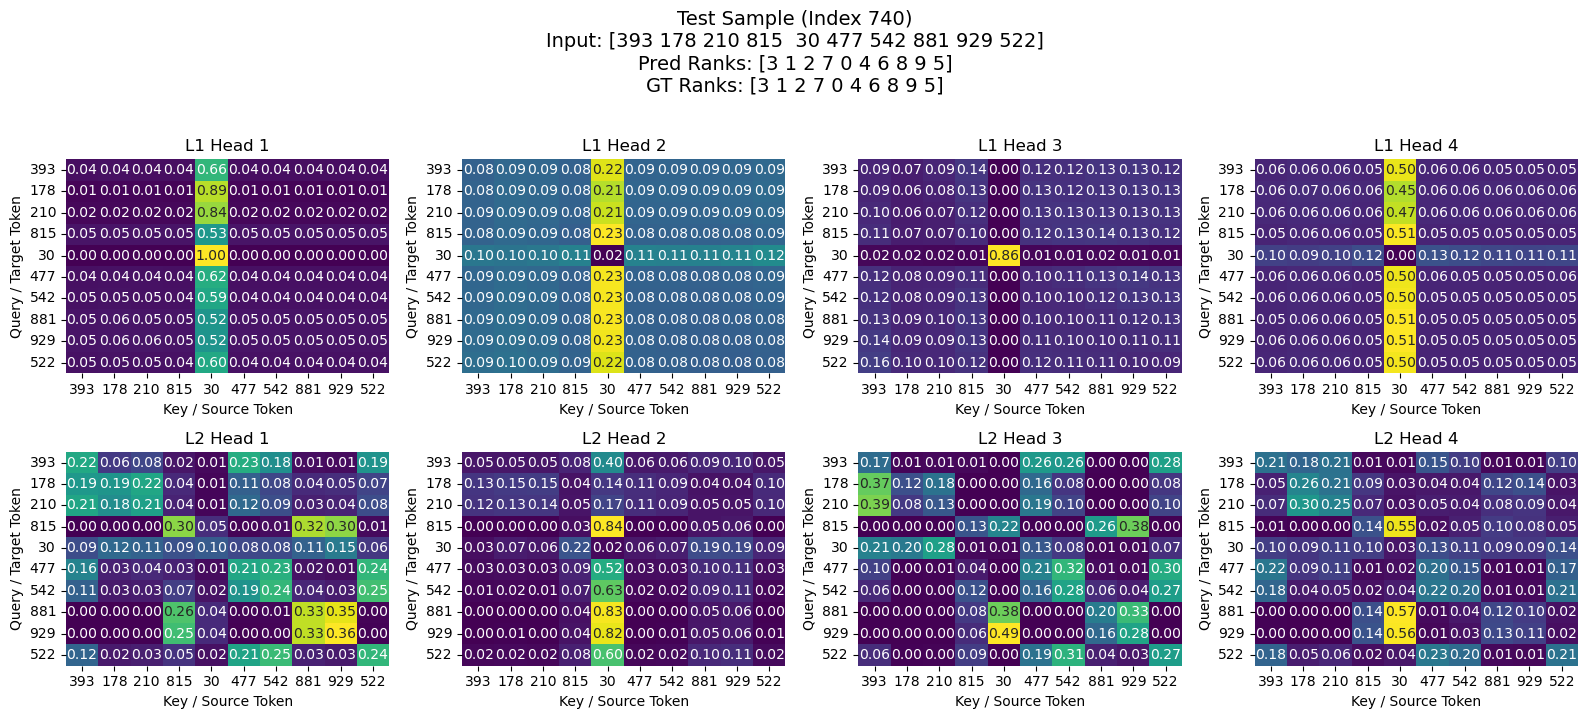

In [ ]:
# Step 9: Visualize a few sample sequences from the test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)
for idx in sample_indices:
    seq = X_test[idx]
    gt_ranks = y_test[idx]
    
    # Model prediction
    logits = model(jnp.array([seq], dtype=jnp.float32))
    pred_ranks = np.array(jnp.argmax(logits, axis=-1)[0])
    plot_attention_heatmaps(model, seq, pred_ranks, gt_ranks, title=f"Test Sample (Index {idx})")


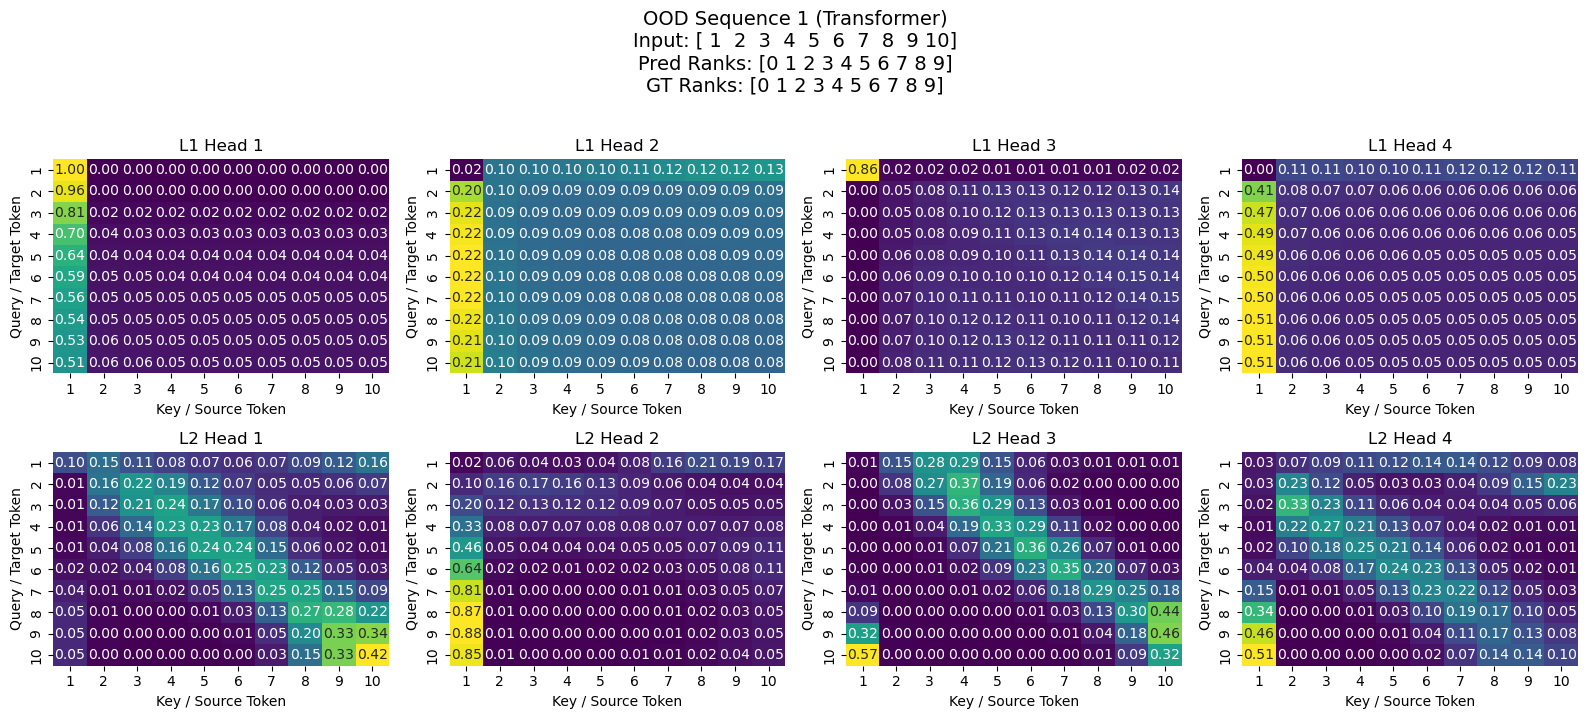

OOD Sequence 1 | GT Ranks: [0 1 2 3 4 5 6 7 8 9]
  Transformer Predicted Ranks: [0 1 2 3 4 5 6 7 8 9]
  MLP Baseline Predicted Ranks: [0 1 2 3 4 5 6 7 8 9]
  LSTM Baseline Predicted Ranks: [0 1 2 3 3 6 6 7 8 9]



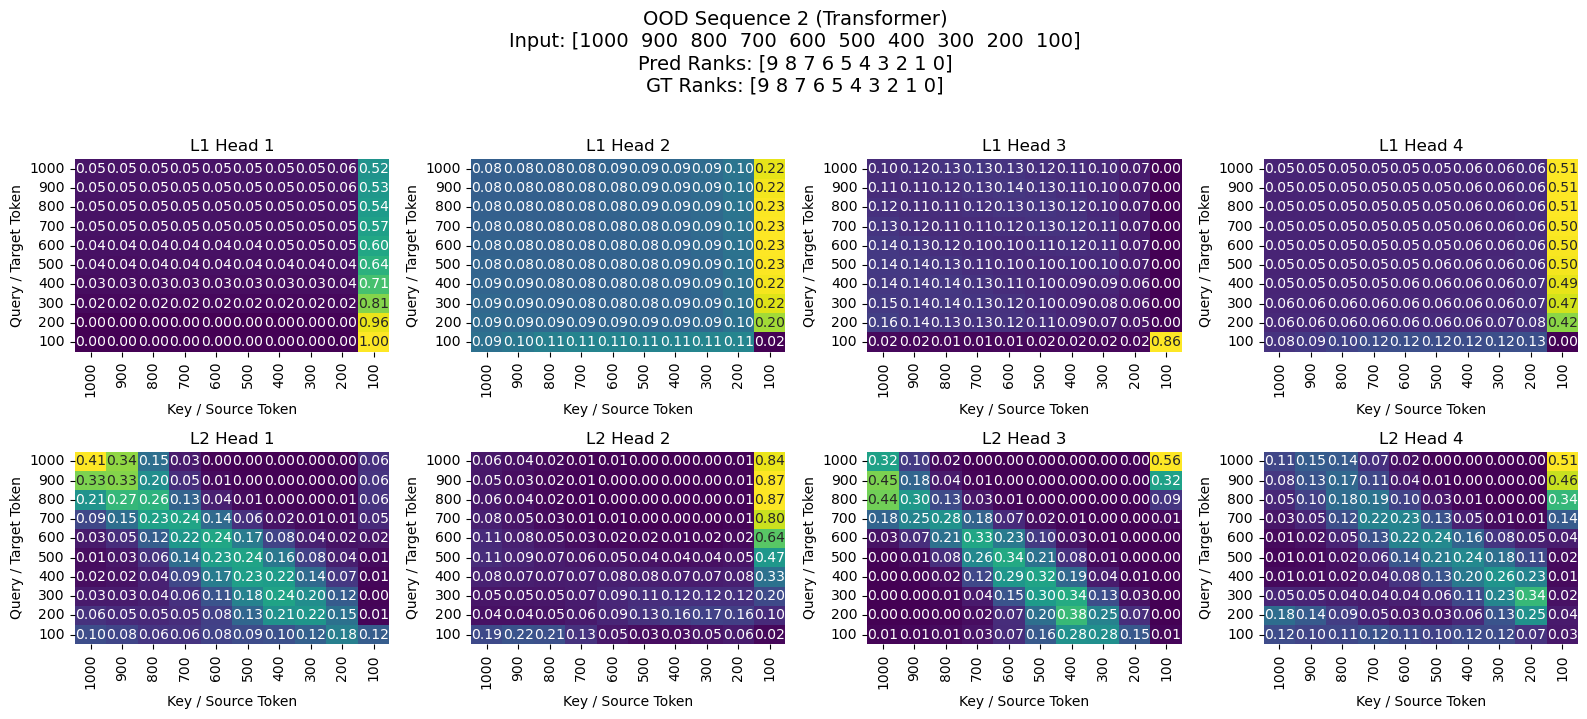

OOD Sequence 2 | GT Ranks: [9 8 7 6 5 4 3 2 1 0]
  Transformer Predicted Ranks: [9 8 7 6 5 4 3 2 1 0]
  MLP Baseline Predicted Ranks: [9 8 7 6 5 4 3 2 1 0]
  LSTM Baseline Predicted Ranks: [9 8 7 6 5 5 3 2 1 0]



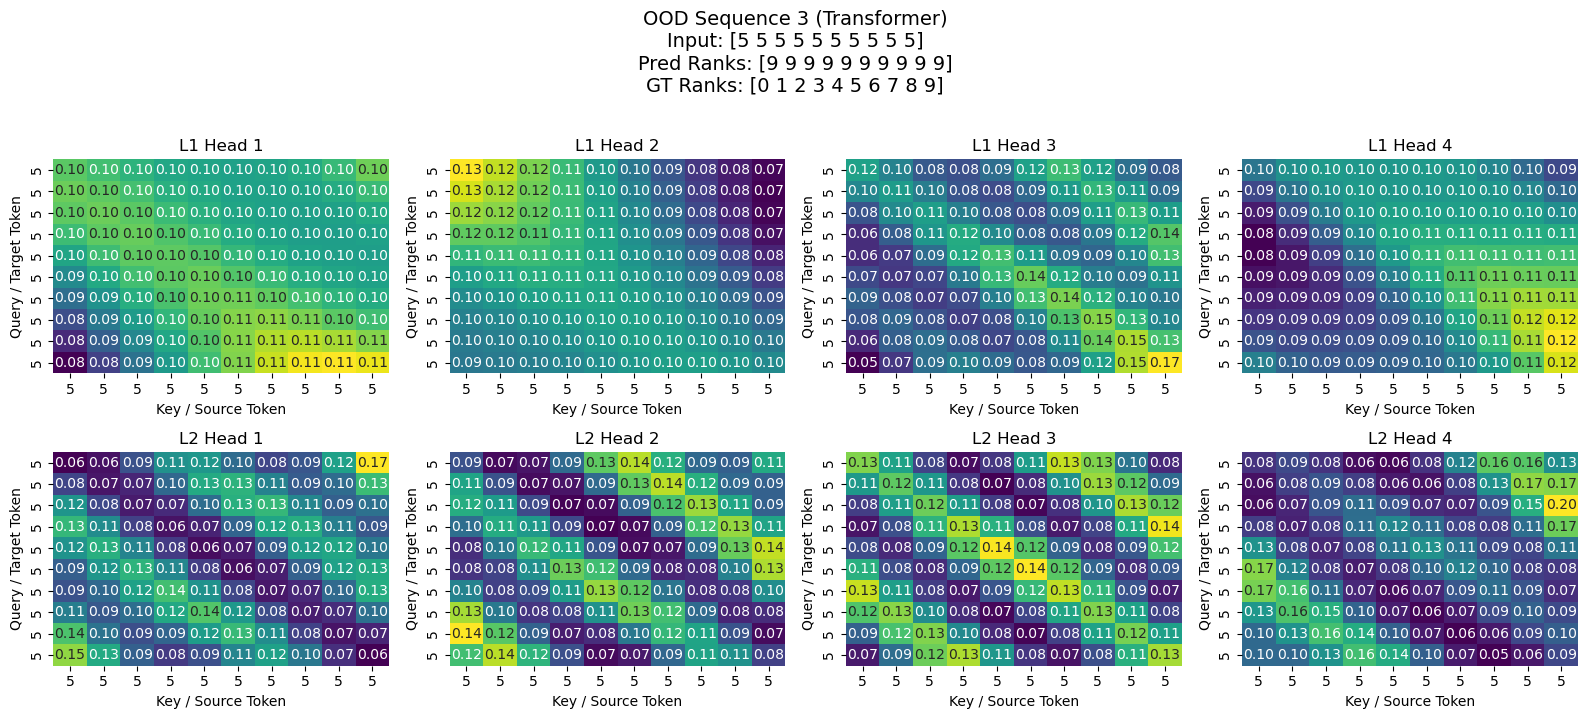

OOD Sequence 3 | GT Ranks: [0 1 2 3 4 5 6 7 8 9]
  Transformer Predicted Ranks: [9 9 9 9 9 9 9 9 9 9]
  MLP Baseline Predicted Ranks: [6 6 6 6 6 6 6 6 6 6]
  LSTM Baseline Predicted Ranks: [0 3 3 4 4 4 4 4 3 3]



In [ ]:
# Step 10: Out-of-Distribution (OOD) Testing
ood_sequences = [
    np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]),
    np.array([1000, 900, 800, 700, 600, 500, 400, 300, 200, 100]),
    np.array([5, 5, 5, 5, 5, 5, 5, 5, 5, 5])
]

for i, seq in enumerate(ood_sequences):
    gt_ranks = stable_rank(seq)
    
    # Transformer predictions
    logits = model(jnp.array([seq], dtype=jnp.float32))
    pred_ranks = np.array(jnp.argmax(logits, axis=-1)[0])
    plot_attention_heatmaps(model, seq, pred_ranks, gt_ranks, title=f"OOD Sequence {i+1} (Transformer)")
    
    # MLP baseline predictions
    mlp_logits = mlp_model(jnp.array([seq], dtype=jnp.float32))
    mlp_pred_ranks = np.array(jnp.argmax(mlp_logits, axis=-1)[0])
    
    # LSTM baseline predictions
    lstm_logits = lstm_model(jnp.array([seq], dtype=jnp.float32))
    lstm_pred_ranks = np.array(jnp.argmax(lstm_logits, axis=-1)[0])
    
    print(f"OOD Sequence {i+1} | GT Ranks: {gt_ranks}")
    print(f"  Transformer Predicted Ranks: {pred_ranks}")
    print(f"  MLP Baseline Predicted Ranks: {mlp_pred_ranks}")
    print(f"  LSTM Baseline Predicted Ranks: {lstm_pred_ranks}\n")
